QiXiang — Inference notebook

Purpose: Load the ATIS dataset from Hugging Face, load a saved model checkpoint (if present), and run evaluation. This notebook will not retrain the model.

In [25]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
%pip install numpy matplotlib seaborn tqdm scikit-learn pandas jupyterlab

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
# Imports & device
import os
from pathlib import Path
import sys

import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ensure repo root on path so we can import model helper
ROOT = os.path.abspath(os.path.join("..", "..", ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

from src.RNN.QiXiang_model.model import (
    load_vocab,
    save_vocab,
    load_checkpoint,
    get_model,
    VOCAB_PATH,
    MAX_LEN,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [27]:
# Load ATIS dataset from Hugging Face
dataset = load_dataset("tuetschek/atis")
train = dataset["train"]
test = dataset["test"]

selected_intents = [
    "flight",
    "airfare",
    "airline",
    "flight_no",
    "flight_time",
    "ground_service",
    "distance",
    "city"
]

# Make small pandas views (only the fields we need)
df_train = pd.DataFrame({"text": train["text"], "intent": train["intent"]})
df_test  = pd.DataFrame({"text": test["text"],  "intent": test["intent"]})

# filter to selected intents
df_train = df_train[df_train["intent"].isin(selected_intents)].reset_index(drop=True)
df_test  = df_test[df_test["intent"].isin(selected_intents)].reset_index(drop=True)

print("Train size:", len(df_train), "| Test size:", len(df_test))

Train size: 4606 | Test size: 779


In [28]:
# Clean text and build/load vocab
import re
from collections import Counter

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

MAX_LEN = 20

df_train["clean_text"] = df_train["text"].apply(clean_text)
df_test["clean_text"]  = df_test["text"].apply(clean_text)

# Try load vocab; if missing, build and save (this keeps inference working without manual steps)
vocab = load_vocab()
if vocab is None:
    print("No saved vocab found. Building vocab from training split and saving it.")
    all_words = " ".join(df_train["clean_text"]).split()
    word_freq = Counter(all_words)
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for w in word_freq:
        vocab[w] = len(vocab)
    save_vocab(vocab)
else:
    print("Loaded vocab from disk.")

print("Vocab size:", len(vocab))

label2idx = {label: idx for idx, label in enumerate(selected_intents)}
idx2label = {idx: label for label, idx in label2idx.items()}
num_classes = len(label2idx)

Loaded vocab from disk.
Vocab size: 676


In [29]:
# Encode function and dataset wrapper
import torch
from torch.utils.data import Dataset, DataLoader

def encode_text(text, vocab, max_len=MAX_LEN):
    tokens = text.split()
    seq = [vocab.get(w, vocab["<UNK>"]) for w in tokens]
    seq = seq[:max_len]
    seq += [vocab["<PAD>"]] * (max_len - len(seq))
    return seq

class IntentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.X = torch.tensor([encode_text(t, vocab) for t in texts], dtype=torch.long)
        self.y = torch.tensor([label2idx[l] for l in labels], dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


test_ds = IntentDataset(df_test["clean_text"].tolist(), df_test["intent"].tolist(), vocab)

test_dl = DataLoader(test_ds, batch_size=32)

In [30]:
# Load model and checkpoint (no training here)
model = get_model(
    "bilstm",
    vocab_size=len(vocab),
    embed_dim=100,
    hidden_dim=128,
    num_classes=num_classes,
    dropout=0.3,
)
model.to(DEVICE)

from pathlib import Path
CHECKPOINT = Path("models") / "RNN" / "QiXiang_model" / "best.pt"

# If you want the notebook to create a checkpoint automatically when missing,
# set DO_QUICK_TRAIN = True below. By default this is False to avoid accidental training runs during inference.
DO_QUICK_TRAIN = False  # change to True to run a 1-epoch quick train and save checkpoint

# Prepare a small training DataLoader so quick-train can run if enabled
from torch.utils.data import DataLoader
train_ds = IntentDataset(df_train["clean_text"].tolist(), df_train["intent"].tolist(), vocab)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

if not load_checkpoint(model, CHECKPOINT, DEVICE):
    if DO_QUICK_TRAIN:
        print(f"No checkpoint found at {CHECKPOINT}. Running a short quick-train to create one (1 epoch).")
        model.train()
        import torch.optim as optim
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
        EPOCHS_QUICK = 1
        for epoch in range(EPOCHS_QUICK):
            total_loss = 0
            for Xb, yb in train_dl:
                Xb = Xb.to(DEVICE)
                yb = yb.to(DEVICE)
                optimizer.zero_grad()
                out = model(Xb)
                loss = criterion(out, yb)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            print(f"Quick-train epoch {epoch+1} loss: {total_loss/len(train_dl):.4f}")
        CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), CHECKPOINT)
        print("Saved quick checkpoint to", CHECKPOINT)
    else:
        print(
            f"No checkpoint found at {CHECKPOINT}. To evaluate properly, either:\n"
            " - Run the training notebook to create a checkpoint, or\n"
            " - Set DO_QUICK_TRAIN = True (and run this cell) to create a small checkpoint automatically.\n"
            "Proceeding with the uninitialized model (results may be poor)."
        )
else:
    print("Loaded checkpoint. Running evaluation...")

model.eval()

Loaded checkpoint. Running evaluation...


c:\Users\snow1\OneDrive\Apps\Desktop\Y2S2\CVNL\CVNL_ASSG_Team4\src\RNN\QiXiang_model\model.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.l

IntentBiLSTM(
  (embedding): Embedding(676, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=8, bias=True)
)

                precision    recall  f1-score   support

        flight       0.95      0.97      0.96       632
       airfare       0.66      0.94      0.78        48
       airline       1.00      0.37      0.54        38
     flight_no       0.00      0.00      0.00         8
   flight_time       0.00      0.00      0.00         1
ground_service       0.65      0.92      0.76        36
      distance       0.00      0.00      0.00        10
          city       0.00      0.00      0.00         6

      accuracy                           0.91       779
     macro avg       0.41      0.40      0.38       779
  weighted avg       0.89      0.91      0.89       779



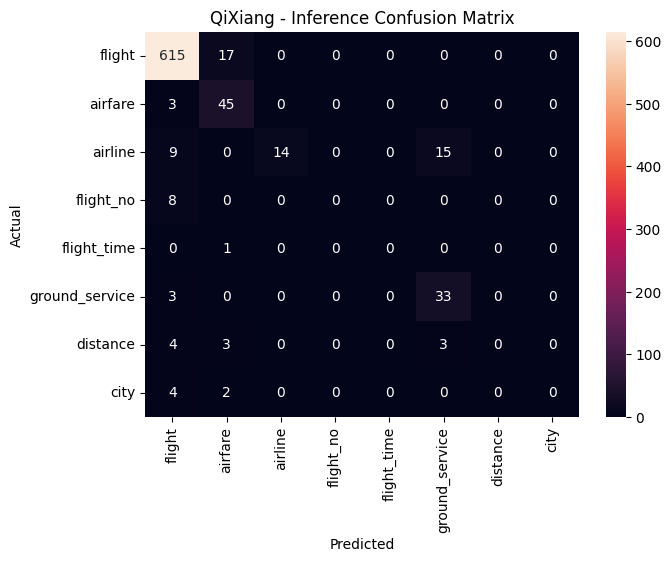

In [31]:
# Run inference and report
from sklearn.metrics import classification_report

y_true, y_pred = [], []

with torch.no_grad():
    for Xb, yb in test_dl:
        Xb = Xb.to(DEVICE)
        out = model(Xb)
        preds = torch.argmax(out, dim=1).cpu().tolist()
        y_pred.extend(preds)
        y_true.extend(yb.tolist())

labels = sorted(set(y_true) | set(y_pred))

print(classification_report(y_true, y_pred, labels=labels, target_names=[idx2label[i] for i in labels], zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=[idx2label[i] for i in labels], yticklabels=[idx2label[i] for i in labels])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("QiXiang - Inference Confusion Matrix")
plt.show()